# 03 — Parameter Sweep Analysis

Analysis of parameter sweep results from `experiments/sweep.py`.
Each experiment varies one parameter and runs with multiple seeds.


In [6]:
import os
import pandas as pd
import matplotlib.pyplot as plt

LOG_DIR = "../experiments/logs"

# Load sweep summary
summary = pd.read_csv(os.path.join(LOG_DIR, "sweep_summary.csv"))
print(f"Total runs: {len(summary)}")
summary.head()


Total runs: 84


,experiment,seed,run_id
0,selection_tournament,42,selection_tournament_seed42
1,selection_tournament,123,selection_tournament_seed123
2,selection_tournament,456,selection_tournament_seed456
3,selection_roulette,42,selection_roulette_seed42
4,selection_roulette,123,selection_roulette_seed123


In [7]:
def load_log(run_id):
    path = os.path.join(LOG_DIR, f"{run_id}.csv")
    return pd.read_csv(path)

def plot_group(group_prefix, title):
    """Plot convergence curves for all experiments matching a prefix."""
    runs = summary[summary["experiment"].str.startswith(group_prefix)]
    
    fig, ax = plt.subplots(figsize=(10, 5))
    for _, row in runs.iterrows():
        log = load_log(row["run_id"])
        ax.plot(log["generation"], log["best_fitness"], alpha=0.7, label=f"{row['experiment']} (seed={row['seed']})")
    
    ax.set_xlabel("Generation")
    ax.set_ylabel("Best Fitness (RMSE)")
    ax.set_title(title)
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

def best_per_experiment(group_prefix):
    """Show mean best fitness per experiment (averaged over seeds)."""
    runs = summary[summary["experiment"].str.startswith(group_prefix)].copy()
    
    results = []
    for exp_name, group in runs.groupby("experiment"):
        fitnesses = []
        for _, row in group.iterrows():
            log = load_log(row["run_id"])
            fitnesses.append(log["best_fitness"].min())
        results.append({"experiment": exp_name, "mean_best": pd.Series(fitnesses).mean(), "std": pd.Series(fitnesses).std()})
    
    return pd.DataFrame(results).sort_values("mean_best")


## Selection method

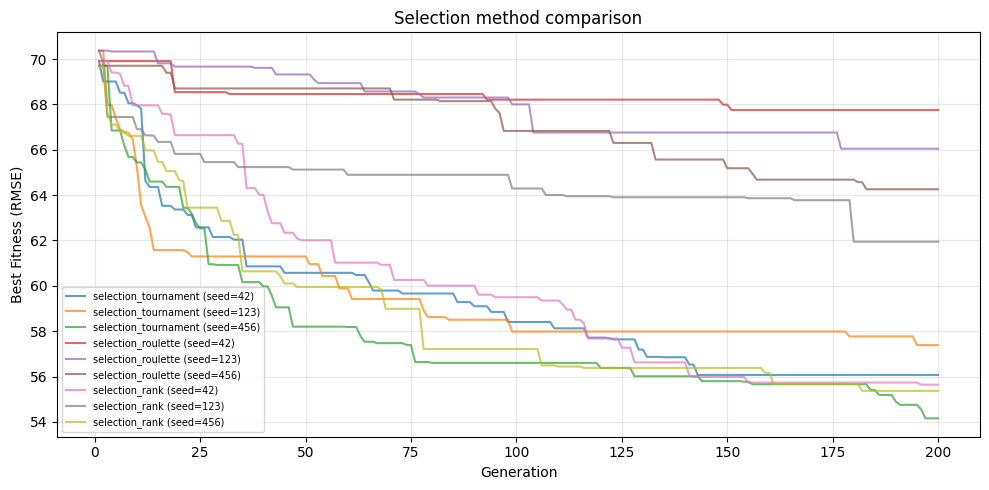

,experiment,mean_best,std
2,selection_tournament,55.871609,1.624029
0,selection_rank,57.651899,3.721543
1,selection_roulette,66.020767,1.748331


In [8]:
plot_group("selection_", "Selection method comparison")
best_per_experiment("selection_")


## Crossover method

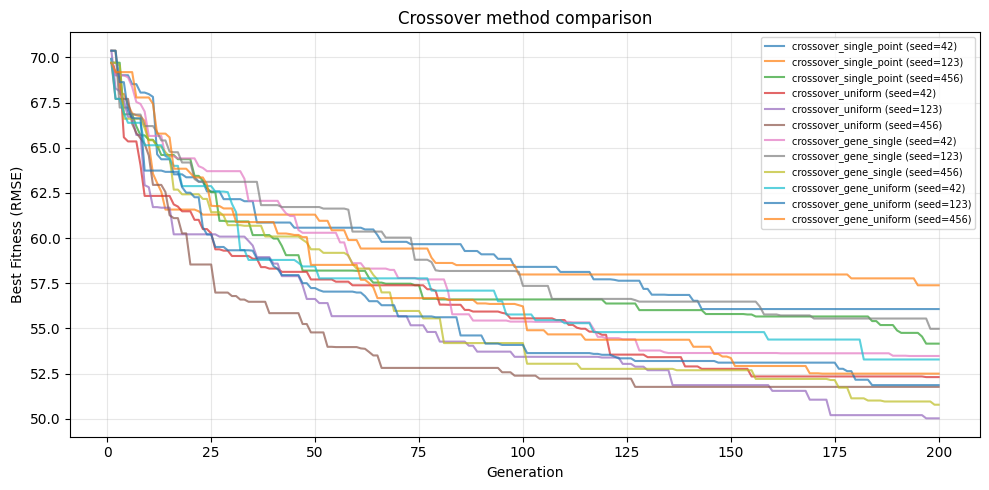

,experiment,mean_best,std
3,crossover_uniform,51.364343,1.192737
1,crossover_gene_uniform,52.546089,0.710500
0,crossover_gene_single,53.076622,2.128611
2,crossover_single_point,55.871609,1.624029


In [9]:
plot_group("crossover_", "Crossover method comparison")
best_per_experiment("crossover_")


## Mutation method

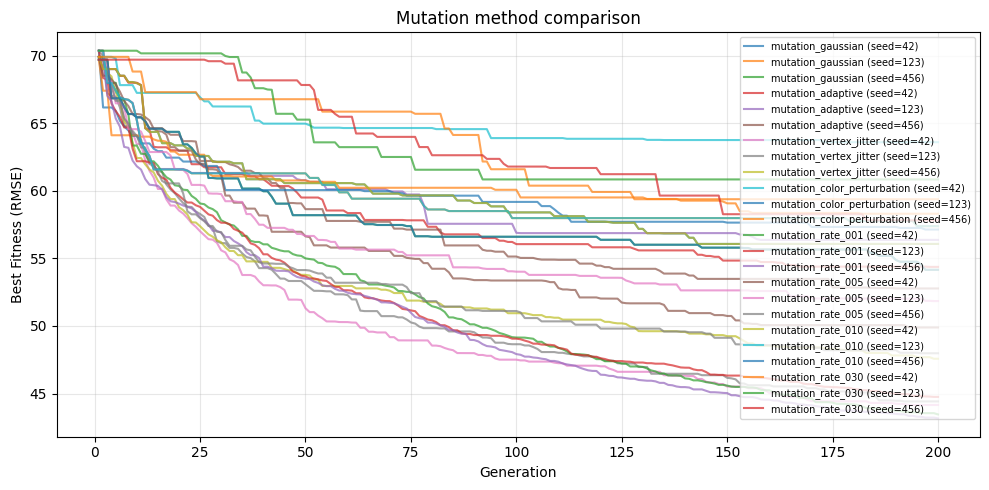

,experiment,mean_best,std
7,mutation_vertex_jitter,45.383989,1.902597
0,mutation_adaptive,54.507201,1.800302
2,mutation_gaussian,55.871609,1.624029
1,mutation_color_perturbation,59.681882,3.444572


In [10]:
methods = ["mutation_gaussian", "mutation_adaptive", "mutation_vertex_jitter", "mutation_color_perturbation"]
plot_group("mutation_", "Mutation method comparison")
best_per_experiment("mutation_").query("experiment in @methods")


## Mutation rate

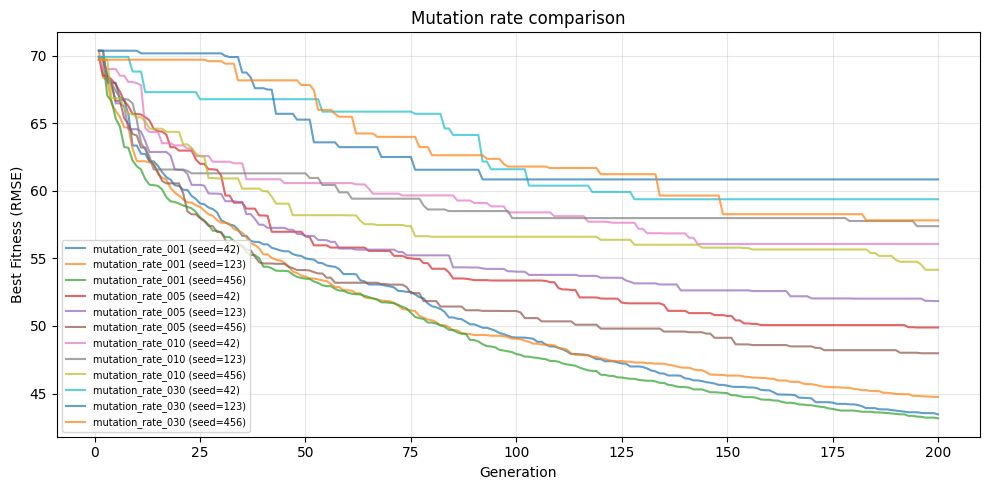

,experiment,mean_best,std
0,mutation_rate_001,43.793574,0.846059
1,mutation_rate_005,49.905829,1.930618
2,mutation_rate_010,55.871609,1.624029
3,mutation_rate_030,59.347773,1.514028


In [11]:
plot_group("mutation_rate_", "Mutation rate comparison")
best_per_experiment("mutation_rate_")


## Sigma

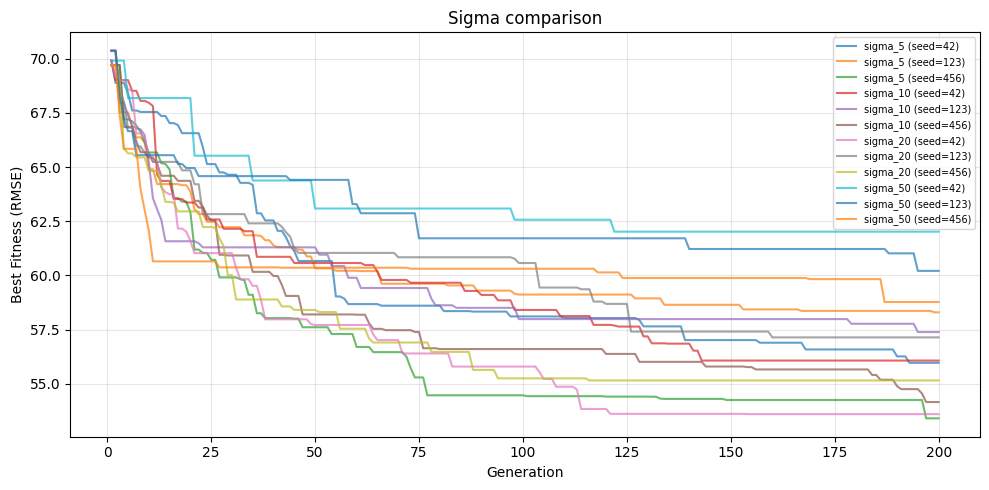

,experiment,mean_best,std
1,sigma_20,55.297916,1.774893
0,sigma_10,55.871609,1.624029
2,sigma_5,55.889291,2.446056
3,sigma_50,60.333888,1.626893


In [12]:
plot_group("sigma_", "Sigma comparison")
best_per_experiment("sigma_")


## Population size

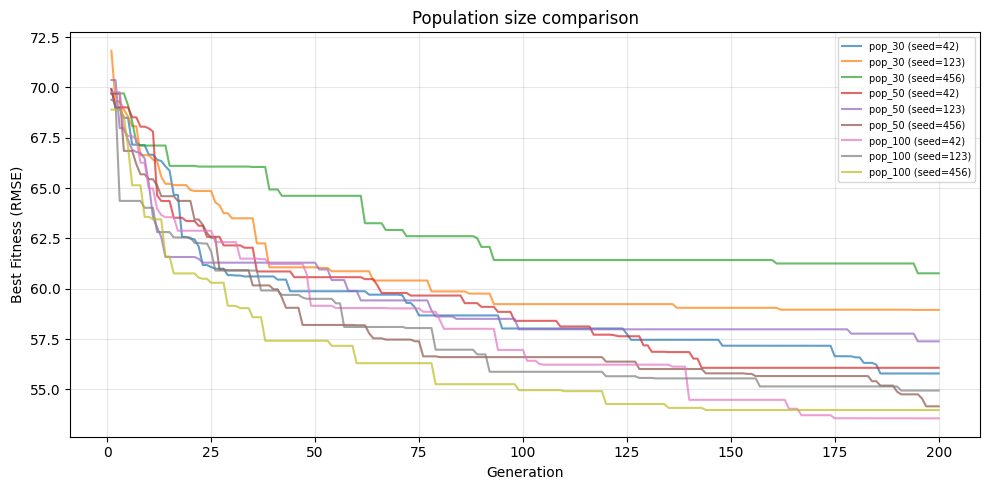

,experiment,mean_best,std
0,pop_100,54.159340,0.708972
2,pop_50,55.871609,1.624029
1,pop_30,58.501745,2.518336


In [13]:
plot_group("pop_", "Population size comparison")
best_per_experiment("pop_")


## Tournament k

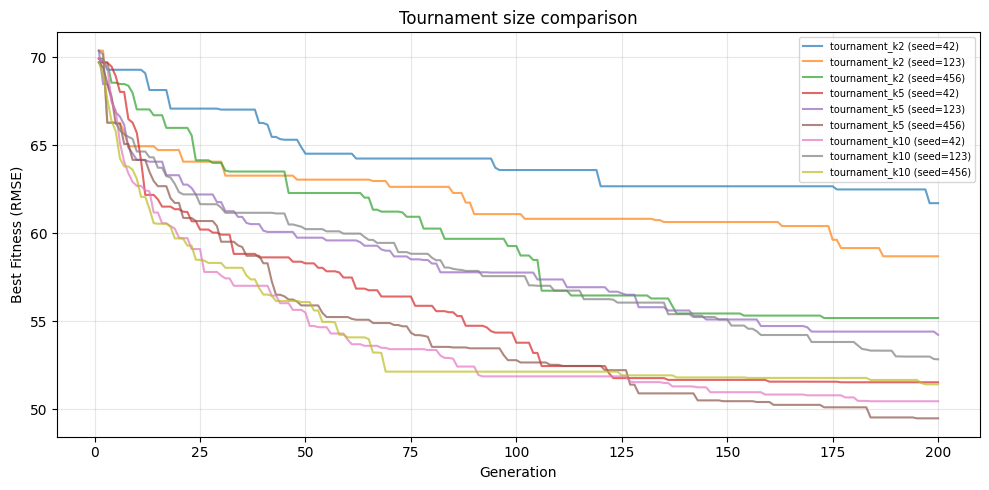

,experiment,mean_best,std
0,tournament_k10,51.573435,1.197458
2,tournament_k5,51.753273,2.379808
1,tournament_k2,58.529903,3.265000


In [14]:
plot_group("tournament_k", "Tournament size comparison")
best_per_experiment("tournament_k")


## Elite size

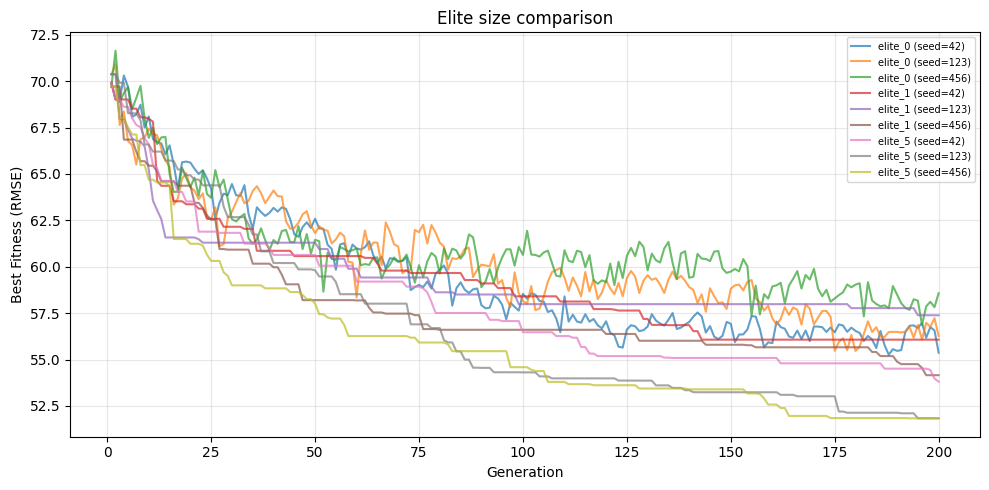

,experiment,mean_best,std
2,elite_5,52.492123,1.141423
0,elite_0,55.864539,0.877019
1,elite_1,55.871609,1.624029


In [15]:
plot_group("elite_", "Elite size comparison")
best_per_experiment("elite_")
